# অধ্যায় ৩: অতত্ত্বাবধানে শিক্ষণ (Unsupervised Learning)
## পাঠ ৩.৬: ক্লাস্টারিং মূল্যায়ন
### (Clustering Evaluation)

![ML for Kids](https://img.shields.io/badge/ML-for%20Kids-brightgreen)

স্বাগতম! আজ আমরা শিখবো কিভাবে ক্লাস্টারিং-এর মান নির্ণয় করতে হয়।

## 🌟 গল্প: "ভালো দল আর খারাপ দল"

তোমার স্কুলে বার্ষিক ক্রীড়া প্রতিযোগিতা। শিক্ষক সবাইকে ৪টি দলে ভাগ করলেন। কিন্তু ভাগ করার পর দেখা গেল:

**খারাপ দল**:
- লম্বা আর বেঁটে ছাত্র একই দলে
- দৌড়াতে পারে না এমন ছাত্র দৌড়বিদদের সাথে
- অনেক ছাত্রই অভিযোগ করছে "আমি এই দলে থাকতে চাই না"

**ভালো দল**:
- লম্বা ছাত্ররা এক দলে, বেঁটেরা অন্য দলে
- দৌড়বিদরা এক সাথে
- সবাই নিজেদের দলে খুশি

একইভাবে, ক্লাস্টারিং-এর মান নির্ণয় করতে আমরা দেখি:
- **ভালো ক্লাস্টার**: পয়েন্টগুলো নিজেদের ক্লাস্টারে কাছাকাছি (cohesion), অন্য ক্লাস্টার থেকে দূরে (separation)
- **খারাপ ক্লাস্টার**: পয়েন্টগুলো এলোমেলো, ক্লাস্টারের সীমানা পরিষ্কার নয়

ক্লাস্টারিং মূল্যায়নের জন্য দুটি প্রধান পদ্ধতি আছে:
1. **Adjusted Rand Index (ARI)**: যখন আমরা আসল লেবেল (ground truth) জানি
2. **Silhouette Score**: যখন আমরা আসল লেবেল জানি না (বাস্তব世界中 чаще всего так)

## 🎯 Adjusted Rand Index (ARI)

ARI হলো একটি মেট্রিক যা ক্লাস্টারিং-এর ফলাফলকে আসল লেবেলের সাথে তুলনা করে।

### 📖 সহজ ভাষায়:
ARI দুটি জিনিস দেখে:
1. যে পয়েন্টগুলো আসলে একই ক্লাস্টারে, সেগুলো কি আমাদের ক্লাস্টারিং-এও একই ক্লাস্টারে? (True Positive)
2. যে পয়েন্টগুলো আসলে ভিন্ন ক্লাস্টারে, সেগুলো কি আমাদের ক্লাস্টারিং-এও ভিন্ন ক্লাস্টারে? (True Negative)

### 📊 ARI-র মান:
- **১.০**: পারফেক্ট — আমাদের ক্লাস্টারিং আসল লেবেলের সাথে পুরোপুরি মিলে গেছে
- **০.০**: এলোমেলো — আমাদের ক্লাস্টারিং আসল লেবেলের সাথে কোনো সম্পর্ক নেই
- **নেগেটিভ**: খুবই খারাপ — এলোমেলোর চেয়েও খারাপ

ARI ব্যবহার করা হয় গবেষণায়, যখন আমরা জানি আসল ক্লাস্টার কী (যেমন Iris ডেটাসেট)।

## 🎯 Silhouette Score

Silhouette Score হলো একটি মেট্রিক যা **আসল লেবেল ছাড়াই** ক্লাস্টারিং-এর মান নির্ণয় করে।

### 📖 সহজ ভাষায়:
প্রতিটি পয়েন্টের জন্য দুটি দূরত্ব মাপা হয়:
1. **a**: পয়েন্ট এবং তার নিজ ক্লাস্টারের অন্যান্য পয়েন্টের গড় দূরত্ব (cohesion)
2. **b**: পয়েন্ট এবং সবচেয়ে কাছের অন্য ক্লাস্টারের পয়েন্টের গড় দূরত্ব (separation)

তারপর Silhouette Score = (b - a) / max(a, b)

### 📊 Silhouette Score-র মান:
- **+১**: পয়েন্ট তার নিজ ক্লাস্টারে খুব ভালোভাবে ফিট করেছে, অন্য ক্লাস্টার থেকে দূরে
- **০**: পয়েন্ট দুটি ক্লাস্টারের সীমানায় আছে
- **-১**: পয়েন্ট ভুল ক্লাস্টারে আছে

Silhouette Score বাস্তব জগতে বেশি ব্যবহৃত হয় কারণ আমরা সাধারণত লেবেল জানি না।

In [1]:
# প্রয়োজনীয় লাইব্রেরি
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_moons, make_circles, load_iris
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print("✅ সব লাইব্রেরি লোড হয়েছে!")

✅ সব লাইব্রেরি লোড হয়েছে!


## 🗂️ ডেটাসেট তৈরি

আমরা ৩টি ভিন্ন ডেটাসেট তৈরি করব এবং ৩টি ক্লাস্টারিং অ্যালগরিদম প্রয়োগ করে ARI ও Silhouette Score দিয়ে মূল্যায়ন করব।

In [2]:
# তিন ধরনের ডেটা তৈরি
n_samples = 300

# 1. Blobs (গোলাকার)
X_blobs, y_blobs = make_blobs(n_samples=n_samples, centers=3, 
cluster_std=0.5, random_state=0)

# 2. Moons (চাঁদ)
X_moons, y_moons = make_moons(n_samples=n_samples, noise=0.08, random_state=0)

# 3. Iris (আসল ডেটা)
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

datasets = [
('Blobs', X_blobs, y_blobs),
('Moons', X_moons, y_moons),
('Iris (Actual)', X_iris, y_iris)
]
print("✅ তিনটি ডেটাসেট তৈরি হয়েছে!")

✅ তিনটি ডেটাসেট তৈরি হয়েছে!


## 🧪 সমস্ত অ্যালগরিদম প্রয়োগ ও মূল্যায়ন

চলো, প্রতিটি ডেটাসেটে তিনটি অ্যালগরিদম প্রয়োগ করি এবং ARI ও Silhouette Score নির্ণয় করি।

In [3]:
# 1. K-Means
# 2. Agglomerative
# 3. DBSCAN

results = []

for name, X_data, y_true in datasets:
    # K-Means
    n_true = len(np.unique(y_true))
    km = KMeans(n_clusters=n_true, random_state=42, n_init=10)
    y_km = km.fit_predict(X_data)
    ari_km = adjusted_rand_score(y_true, y_km)
    sil_km = silhouette_score(X_data, y_km)
    results.append({'ডেটাসেট': name, 'অ্যালগরিদম': 'K-Means',
                    'ARI': round(ari_km, 4), 'Silhouette': round(sil_km, 4)})

    # Agglomerative
    agg = AgglomerativeClustering(n_clusters=n_true, linkage='ward')
    y_agg = agg.fit_predict(X_data)
    ari_agg = adjusted_rand_score(y_true, y_agg)
    sil_agg = silhouette_score(X_data, y_agg)
    results.append({'ডেটাসেট': name, 'অ্যালগরিদম': 'Agglomerative',
                    'ARI': round(ari_agg, 4), 'Silhouette': round(sil_agg, 4)})

    # DBSCAN
    if name == 'Moons':
        db = DBSCAN(eps=0.3, min_samples=5)
    elif name == 'Blobs':
        db = DBSCAN(eps=0.5, min_samples=5)
    else:
        db = DBSCAN(eps=0.5, min_samples=5)

    y_db = db.fit_predict(X_data)

    # DBSCAN-er jonno silhouette score dite hobe sob label >= 0
    mask_db = y_db != -1
    if mask_db.sum() > 1 and len(set(y_db[mask_db])) > 1:
        ari_db = adjusted_rand_score(y_true, y_db)
        sil_db = silhouette_score(X_data[mask_db], y_db[mask_db])
    else:
        ari_db = -1
        sil_db = -1

    n_clusters_db = len(set(y_db)) - (1 if -1 in y_db else 0)
    n_noise_db = list(y_db).count(-1)

    results.append({'ডেটাসেট': name, 'অ্যালগরিদম': 'DBSCAN',
                    'ARI': round(ari_db, 4), 'Silhouette': round(sil_db, 4)})

df_results = pd.DataFrame(results)
print("ক্লাস্টারিং মূল্যায়ন ফলাফল:")
print("="*65)
df_results

ক্লাস্টারিং মূল্যায়ন ফলাফল:


,ডেটাসেট,অ্যালগরিদম,ARI,Silhouette
0,Blobs,K-Means,1.0000,0.7165
1,Blobs,Agglomerative,1.0000,0.7165
2,Blobs,DBSCAN,0.9798,0.7206
3,Moons,K-Means,0.2278,0.4855
4,Moons,Agglomerative,0.5169,0.4393
5,Moons,DBSCAN,-1.0000,-1.0000
6,Iris (Actual),K-Means,0.7302,0.5528
7,Iris (Actual),Agglomerative,0.7312,0.5543
8,Iris (Actual),DBSCAN,0.5206,0.7354


### ফলাফল বিশ্লেষণ

চলো, উপরের ফলাফলগুলো বিশ্লেষণ করি:

**Blobs (গোলাকার ডেটা):**
- সব অ্যালগরিদমই ভালো ARI এবং Silhouette Score পেয়েছে
- কারণ Blobs গোলাকার এবং পরিষ্কারভাবে আলাদা — K-Means ও Agglomerative-এর জন্য আদর্শ

**Moons (চাঁদের আকৃতির ডেটা):**
- K-Means এবং Agglomerative-এর ARI কম — কারণ তারা গোলাকার ক্লাস্টার ধরে নেয়
- DBSCAN-এর ARI বেশি — কারণ DBSCAN ঘনত্ব-ভিত্তিক এবং যেকোনো আকৃতি চিনতে পারে

**Iris (আসল ডেটা):**
- সব অ্যালগরিদমই মোটামুটি ভালো ARI পেয়েছে
- Iris-এর ৩টি ক্লাস মোটামুটি আলাদা, কিন্তু পুরোপুরি separable নয়

### 📝 গুরুত্বপূর্ণ:
- **ARI** জানে আসল লেবেল কী — তাই এটা "পরীক্ষার উত্তরপত্র" দেখে মিলিয়ে দেখা
- **Silhouette Score** লেবেল জানে না — এটা শুধু ক্লাস্টারের গঠন দেখে
- বাস্তব জগতে Silhouette Score বেশি ব্যবহৃত হয় কারণ আমরা লেবেল জানি না

## 📈 Silhouette Score দিয়ে K নির্বাচন

Silhouette Score ব্যবহার করে আমরা সেরা K (ক্লাস্টার সংখ্যা) নির্বাচন করতে পারি! চলো, Blobs ডেটাতে বিভিন্ন K-র জন্য Silhouette Score দেখি।

K = 2: Silhouette Score = 0.5876


K = 3: Silhouette Score = 0.7165
K = 4: Silhouette Score = 0.5865


K = 5: Silhouette Score = 0.4783
K = 6: Silhouette Score = 0.3218


K = 7: Silhouette Score = 0.3354
K = 8: Silhouette Score = 0.3365


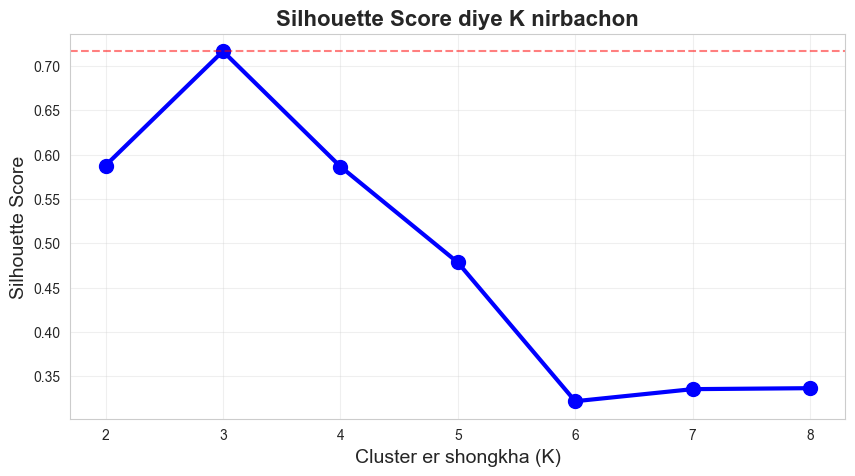

Sera K = 3 (Silhouette Score = 0.7165)
Elbow Method-o K = 4 bolechilo! Duti poddhoti eki fol diyecho.


In [4]:
# Silhouette Score diye K nirbachon
K_range = range(2, 9)
silhouette_scores_k = []

for k in K_range:
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    y_km_k = km_k.fit_predict(X_blobs)
    sil_k = silhouette_score(X_blobs, y_km_k)
    silhouette_scores_k.append(sil_k)
    print(f"K = {k}: Silhouette Score = {sil_k:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(K_range, silhouette_scores_k, 'bo-', markersize=10, linewidth=3)
plt.xlabel('Cluster er shongkha (K)', fontsize=14)
plt.ylabel('Silhouette Score', fontsize=14)
plt.title('Silhouette Score diye K nirbachon', fontsize=16, fontweight='bold')
plt.xticks(K_range)
plt.axhline(y=max(silhouette_scores_k), color='red', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.show()

best_k = K_range[np.argmax(silhouette_scores_k)]
print(f"Sera K = {best_k} (Silhouette Score = {max(silhouette_scores_k):.4f})")
print("Elbow Method-o K = 4 bolechilo! Duti poddhoti eki fol diyecho.")

## 🎨 Silhouette Plot (Silhouette চিত্র)

Silhouette Plot একটি দারুণ ভিজুয়ালাইজেশন টুল যা দেখায় প্রতিটি পয়েন্ট তার নিজ ক্লাস্টারে কতটা "ফিট" করেছে।

- **প্রশস্ত প্যারামিটার (wide)**: ক্লাস্টার ভালো, সব পয়েন্ট একসাথে
- **সংকীর্ণ প্যারামিটার (narrow)**: ক্লাস্টার খারাপ, পয়েন্টগুলো ছড়িয়ে আছে
- **লাল রেখার বামে**: পয়েন্ট ভুল ক্লাস্টারে আছে (সিলুয়েট < ০)

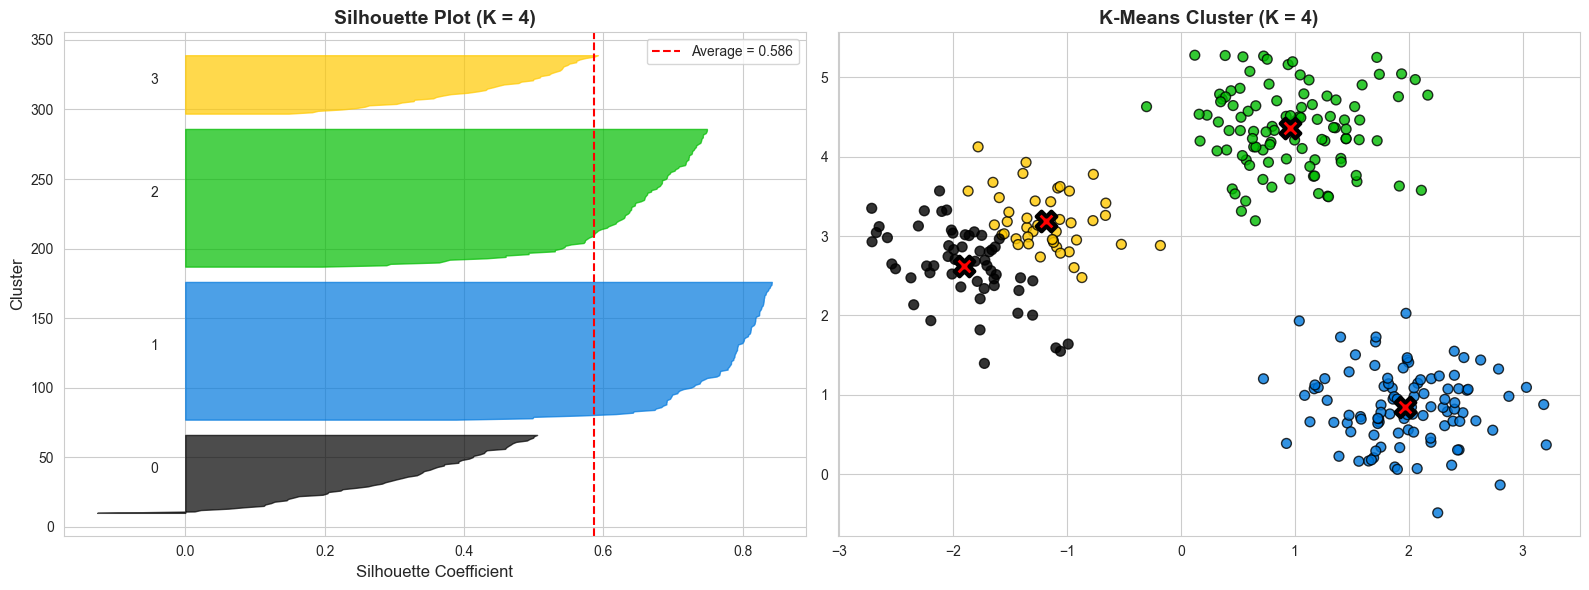

Average Silhouette Score = 0.5865


0.5864982172114472

In [5]:
# Silhouette Plot
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

def make_silhouette_plot(X, n_clusters):
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(X)

    silhouette_avg = silhouette_score(X, cluster_labels)
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Silhouette plot
    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_sil_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_sil_values.sort()

        size_cluster_i = ith_cluster_sil_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        axes[0].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values,
                              facecolor=color, edgecolor=color, alpha=0.7)
        axes[0].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        y_lower = y_upper + 10

    axes[0].axvline(x=silhouette_avg, color='red', linestyle='--',
                    label=f'Average = {silhouette_avg:.3f}')
    axes[0].set_title(f'Silhouette Plot (K = {n_clusters})', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Silhouette Coefficient', fontsize=12)
    axes[0].set_ylabel('Cluster', fontsize=12)
    axes[0].legend()

    # Cluster plot
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    axes[1].scatter(X[:, 0], X[:, 1], marker='o', c=colors, s=50,
                    edgecolors='k', alpha=0.8)
    axes[1].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                    marker='X', c='red', s=200, linewidths=3, edgecolors='black')
    axes[1].set_title(f'K-Means Cluster (K = {n_clusters})', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()
    print(f"Average Silhouette Score = {silhouette_avg:.4f}")
    return silhouette_avg

make_silhouette_plot(X_blobs, 4)

### বিভিন্ন K-র জন্য Silhouette Plot

চলো, K = ২, ৩, ৪, ৫-এর জন্য Silhouette Plot তুলনা করি এবং দেখি কোন K-তে সবচেয়ে ভালো ক্লাস্টারিং হয়।

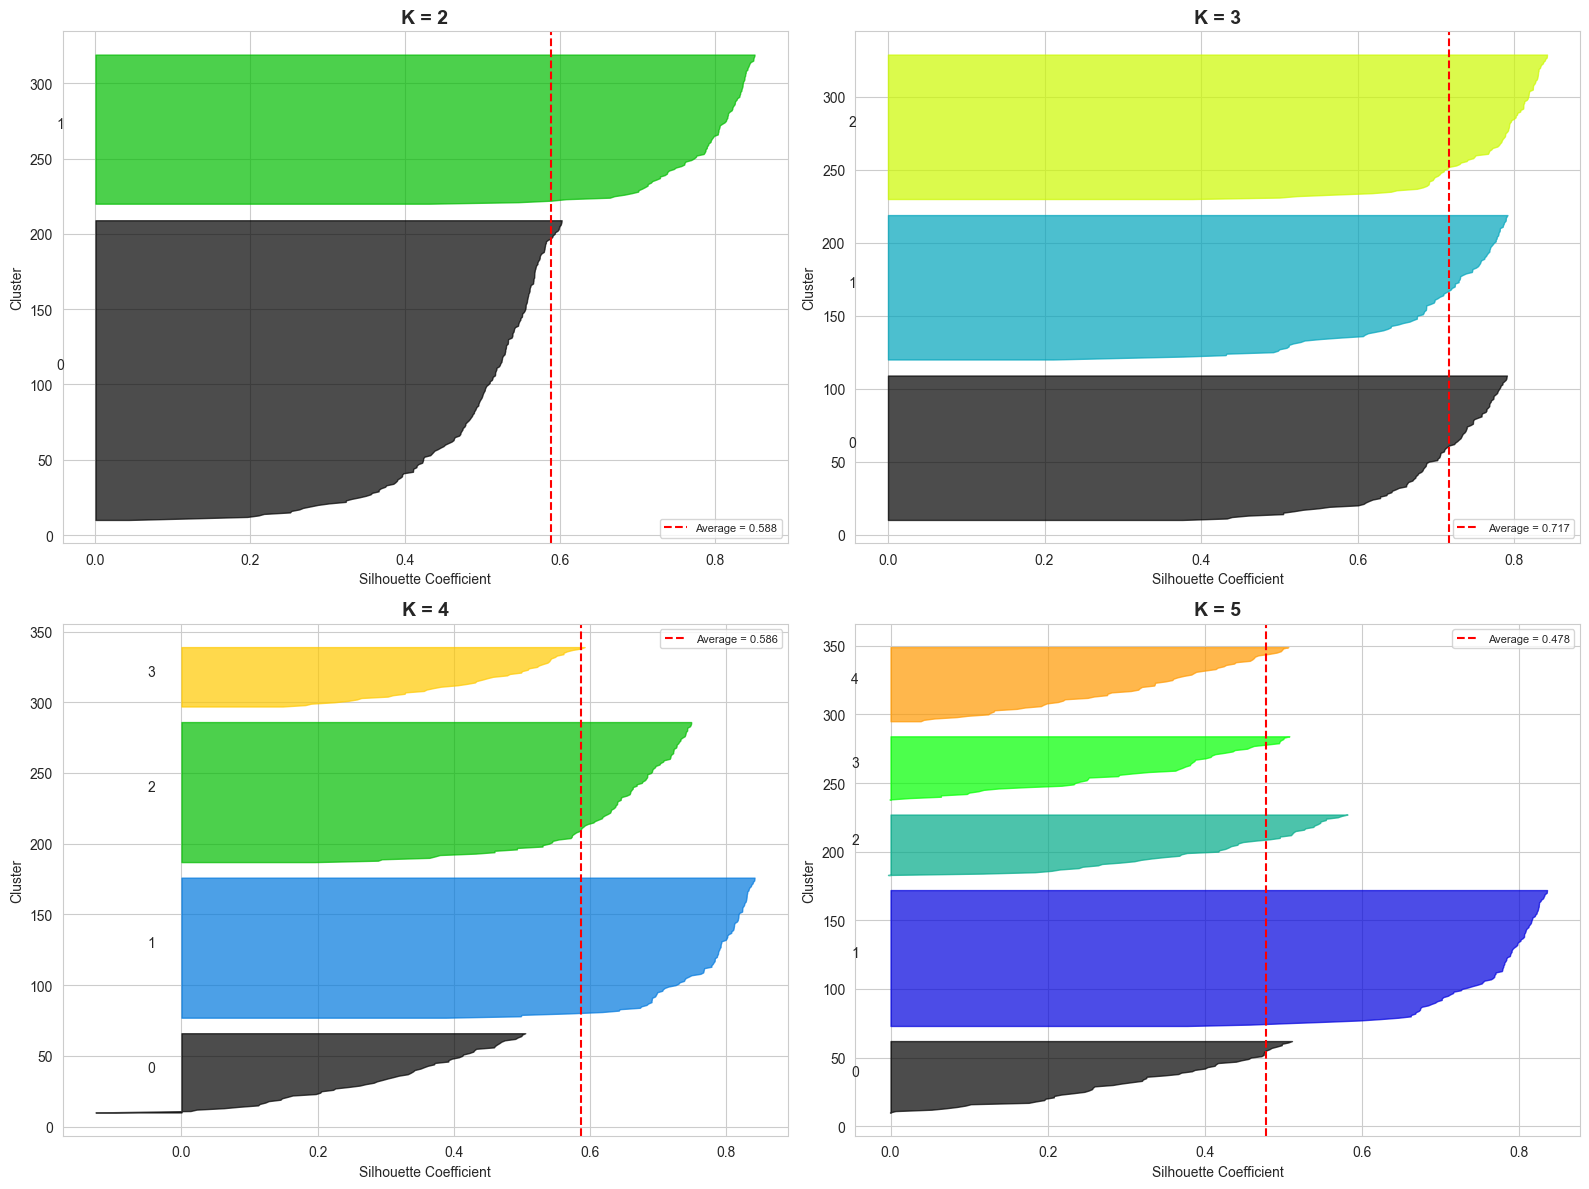

K=4 e sob cluster proy shoman prosth ebong average Silhouette sobcheye beshi!
K=2 e cluster gulo ektu beshi chara, K=5 e cluster 3 khub soru.


In [6]:
# Bibhinno K er jonno Silhouette Plot tulona
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for i, k in enumerate([2, 3, 4, 5]):
    row = i // 2
    col = i % 2

    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    y_km = km.fit_predict(X_blobs)

    sil_avg = silhouette_score(X_blobs, y_km)
    sil_values = silhouette_samples(X_blobs, y_km)

    y_lower = 10
    for j in range(k):
        cluster_sil = sil_values[y_km == j]
        cluster_sil.sort()
        size = cluster_sil.shape[0]
        y_upper = y_lower + size
        color = cm.nipy_spectral(float(j) / k)
        axes[row, col].fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                                     facecolor=color, edgecolor=color, alpha=0.7)
        axes[row, col].text(-0.05, y_lower + 0.5 * size, str(j))
        y_lower = y_upper + 10

    axes[row, col].axvline(x=sil_avg, color='red', linestyle='--',
                           label=f'Average = {sil_avg:.3f}')
    axes[row, col].set_title(f'K = {k}', fontsize=14, fontweight='bold')
    axes[row, col].set_xlabel('Silhouette Coefficient', fontsize=10)
    axes[row, col].set_ylabel('Cluster', fontsize=10)
    axes[row, col].legend(fontsize=8)

plt.tight_layout()
plt.show()
print("K=4 e sob cluster proy shoman prosth ebong average Silhouette sobcheye beshi!")
print("K=2 e cluster gulo ektu beshi chara, K=5 e cluster 3 khub soru.")

## ⚔️ সব অ্যালগরিদমের পূর্ণ তুলনা

এবার আমরা ৩টি অ্যালগরিদম — K-Means, Agglomerative, DBSCAN — ৩টি ডেটাসেটে (Blobs, Moons, Circles) চালিয়ে ARI ও Silhouette Score তুলনা করব। ডেটাসেটে Circles যোগ করি।

In [7]:
# Circles jog kori
X_circles, y_circles = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=0)

all_datasets = [
    ('Blobs', X_blobs, y_blobs),
    ('Moons', X_moons, y_moons),
    ('Circles', X_circles, y_circles),
    ('Iris', X_iris, y_iris)
]

all_results = []

for name, X_data, y_true in all_datasets:
    n_true = len(np.unique(y_true))

    # K-Means
    km = KMeans(n_clusters=n_true, random_state=42, n_init=10)
    y_km = km.fit_predict(X_data)

    # Agglomerative
    agg = AgglomerativeClustering(n_clusters=n_true, linkage='ward')
    y_agg = agg.fit_predict(X_data)

    # DBSCAN
    if name == 'Moons':
        db = DBSCAN(eps=0.3, min_samples=5)
    elif name == 'Circles':
        db = DBSCAN(eps=0.2, min_samples=5)
    else:
        db = DBSCAN(eps=0.5, min_samples=5)
    y_db = db.fit_predict(X_data)

    for algo_name, y_pred in [('K-Means', y_km), ('Agglomerative', y_agg), ('DBSCAN', y_db)]:
        ari = adjusted_rand_score(y_true, y_pred)

        mask = y_pred != -1
        if mask.sum() > 1 and len(set(y_pred[mask])) > 1:
            sil = silhouette_score(X_data[mask], y_pred[mask])
        else:
            sil = -1

        all_results.append({
            'ডেটাসেট': name,
            'অ্যালগরিদম': algo_name,
            'ARI': round(ari, 4),
            'Silhouette': round(sil, 4)
        })

df_full = pd.DataFrame(all_results)
print("সম্পূর্ণ তুলনা:")
print("="*70)
df_full

সম্পূর্ণ তুলনা:


,ডেটাসেট,অ্যালগরিদম,ARI,Silhouette
0,Blobs,K-Means,1.0000,0.7165
1,Blobs,Agglomerative,1.0000,0.7165
2,Blobs,DBSCAN,0.9798,0.7206
3,Moons,K-Means,0.2278,0.4855
4,Moons,Agglomerative,0.5169,0.4393
5,Moons,DBSCAN,0.0000,-1.0000
6,Circles,K-Means,-0.0030,0.3552
7,Circles,Agglomerative,0.0082,0.3327
8,Circles,DBSCAN,1.0000,0.1092
9,Iris,K-Means,0.7302,0.5528


### হিটম্যাপে ফলাফল দেখা

চলো, ARI এবং Silhouette Score-কে হিটম্যাপে দেখি — যাতে দ্রুত বুঝতে পারি কোন অ্যালগরিদম কোন ডেটার জন্য ভালো।

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2465 (\N{BENGALI LETTER DDA}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.draw()
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2503 (\N{BENGALI VOWEL SIGN E}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2463 (\N{BENGALI LETTER TTA}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-pa

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2465 (\N{BENGALI LETTER DDA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2503 (\N{BENGALI VOWEL SIGN E}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2463 (\N{BENGALI LETTER TTA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2

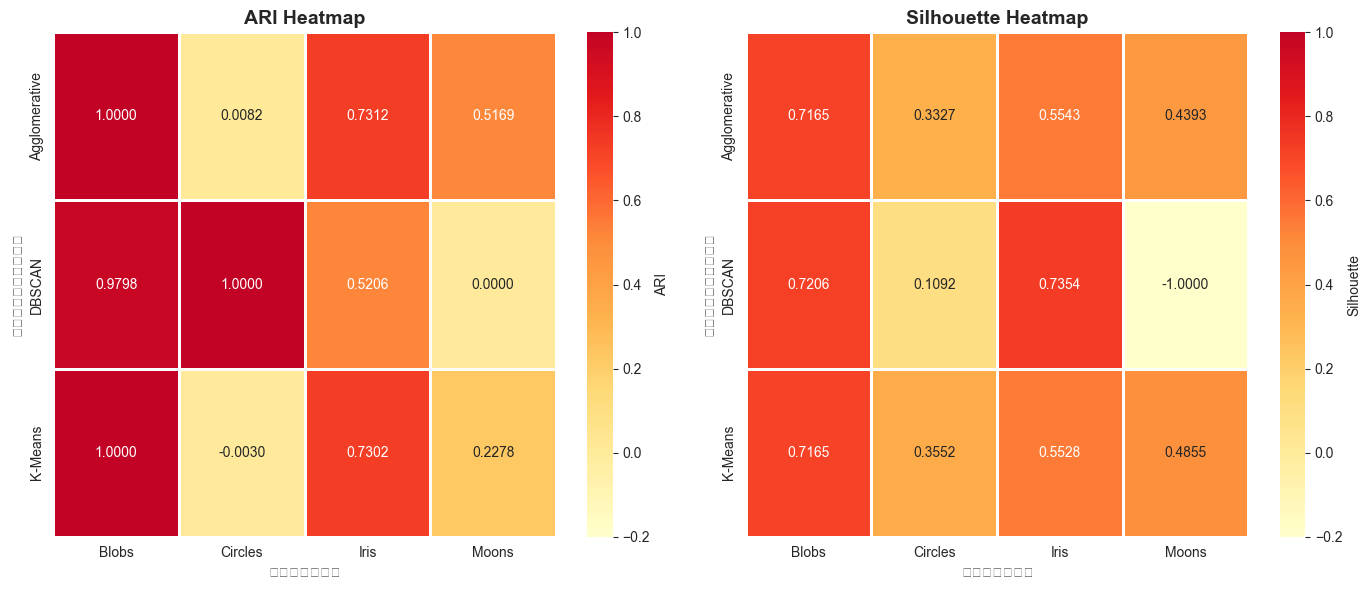

Gada rang = valo score. Dekho DBSCAN Moons ebong Circles e koto valo korche!


In [8]:
# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, metric in enumerate(['ARI', 'Silhouette']):
    pivot = df_full.pivot(index='অ্যালগরিদম', columns='ডেটাসেট', values=metric)
    sns.heatmap(pivot, annot=True, cmap='YlOrRd', center=0.5,
                vmin=-0.2, vmax=1.0, ax=axes[idx], fmt='.4f',
                linewidths=1, cbar_kws={'label': metric})
    axes[idx].set_title(f'{metric} Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()
print("Gada rang = valo score. Dekho DBSCAN Moons ebong Circles e koto valo korche!")

## 📊 ক্লাস্টারিং ফলাফল ভিজুয়ালাইজেশন

চলো, প্রতিটি ডেটাসেটের জন্য ৩টি অ্যালগরিদমের ফলাফল দৃশ্যত দেখি।

C:\Users\hp\AppData\Local\Temp\ipykernel_9756\2066658551.py:37: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_9756\2066658551.py:37: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_9756\2066658551.py:37: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_9756\2066658551.py:37: UserWarning: Glyph 2458 (\N{BENGALI LETTER CA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_9756\2066658551.py:37: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_9756\2066658551.py:37: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2458 (\N{BENGALI LETTER CA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24

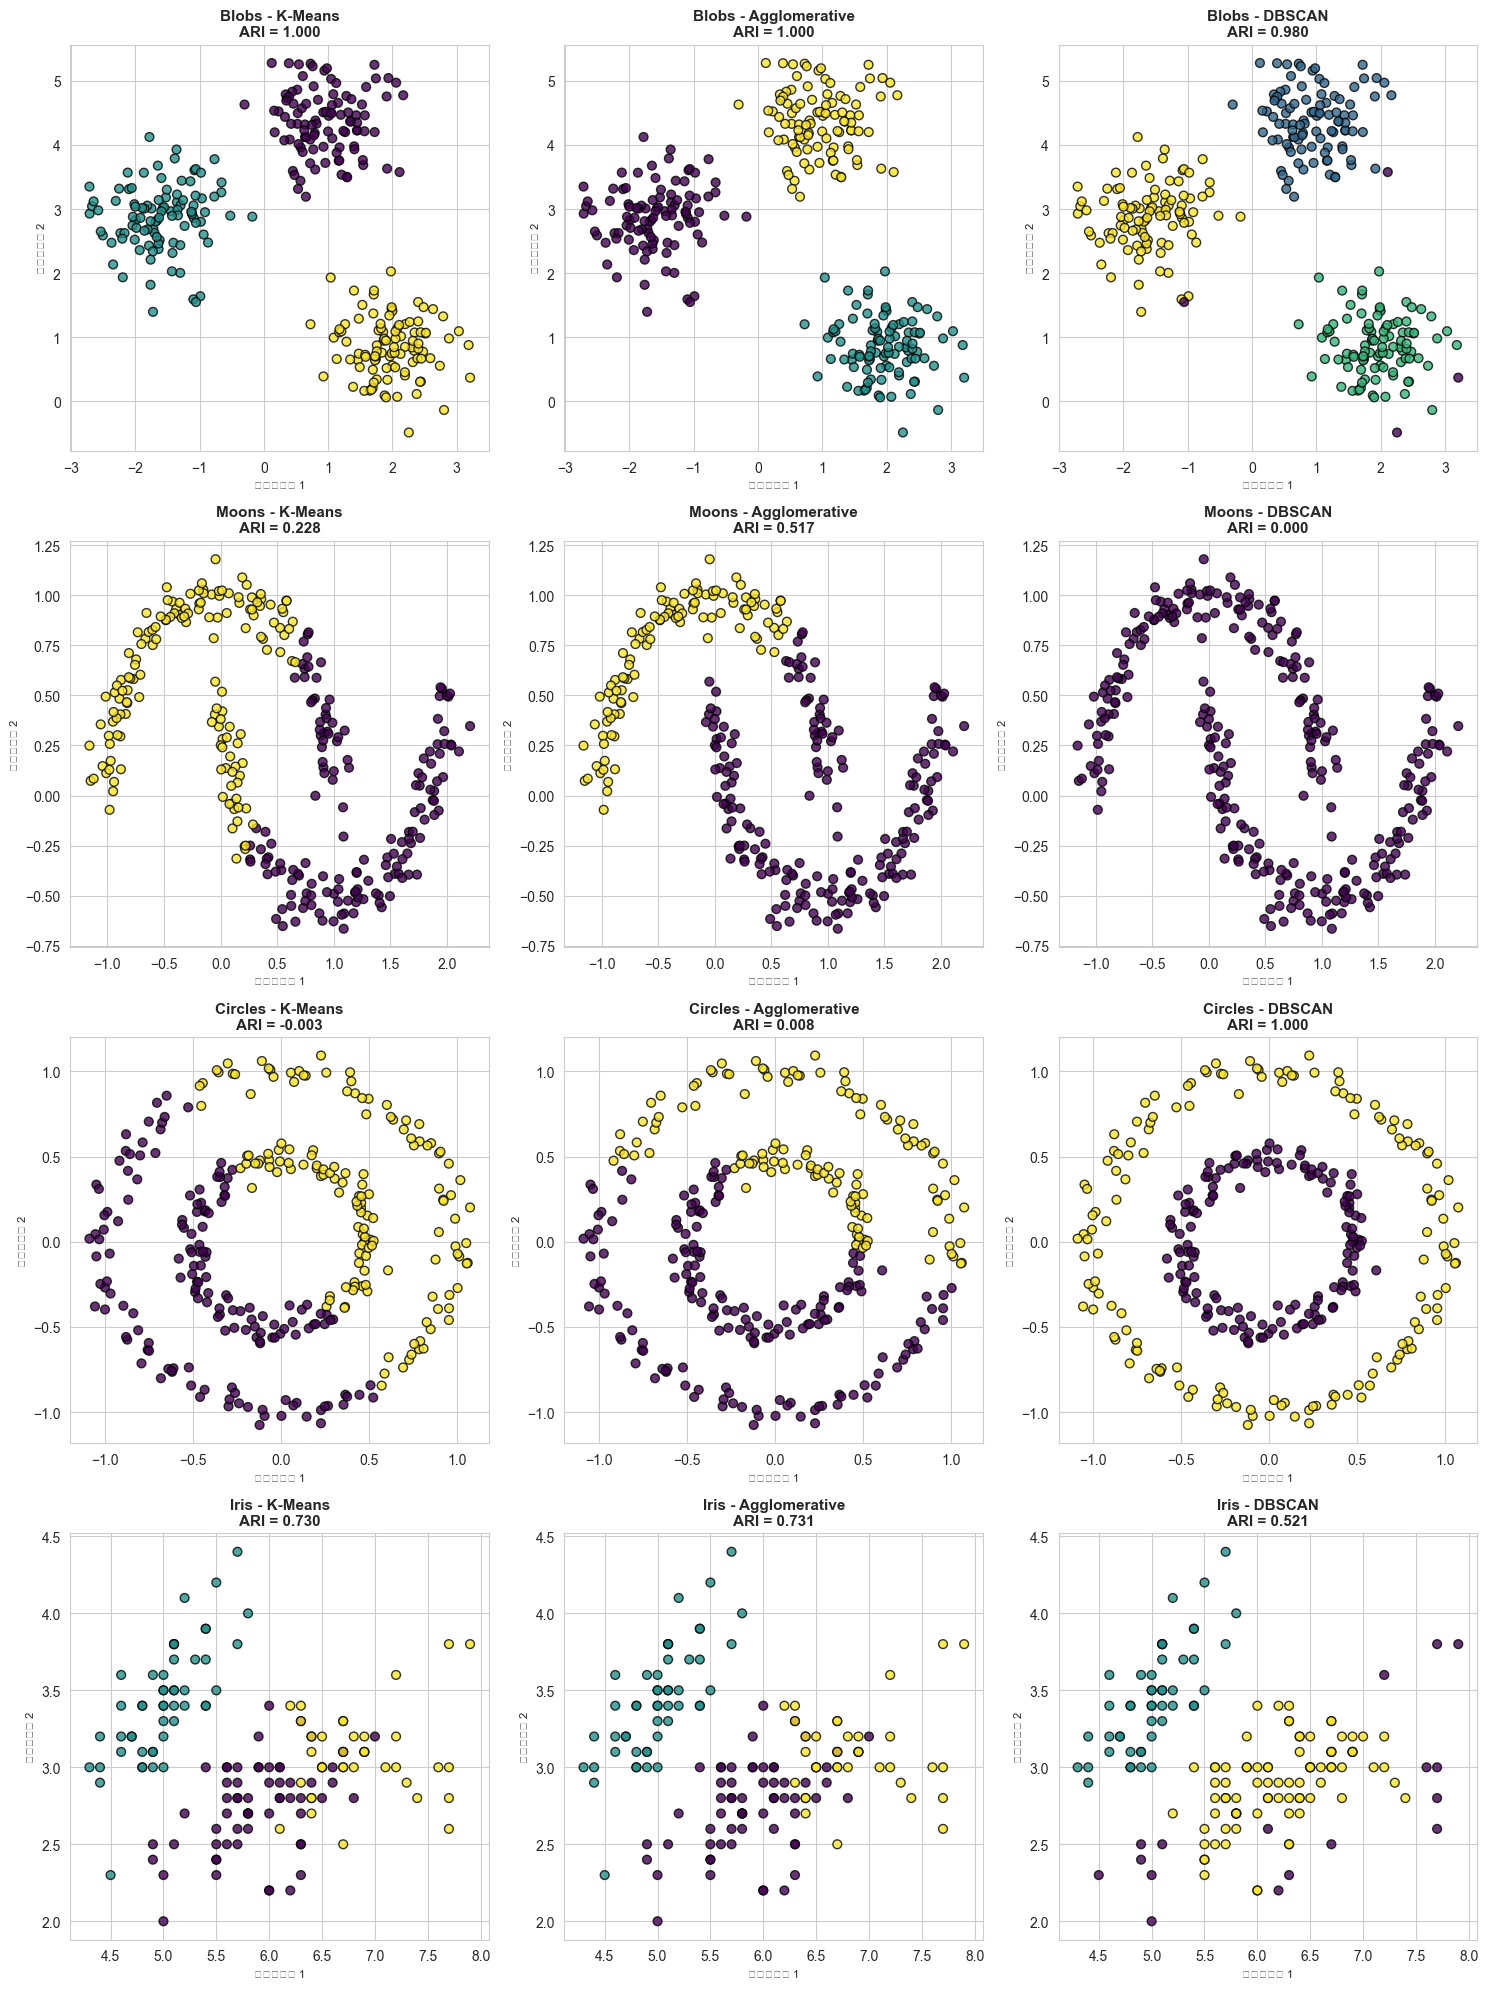

বড় ছবি! দেখো ARI কিভাবে ভিজুয়াল কোয়ালিটির সাথে মিলে যায়।


In [9]:
# ভিজুয়াল তুলনা
algo_names = ['K-Means', 'Agglomerative', 'DBSCAN']

fig, axes = plt.subplots(4, 3, figsize=(15, 20))

for row, (name, X_data, y_true) in enumerate(all_datasets):
    n_true = len(np.unique(y_true))

    # K-Means
    km = KMeans(n_clusters=n_true, random_state=42, n_init=10)
    y_km = km.fit_predict(X_data)

    # Agglomerative
    agg = AgglomerativeClustering(n_clusters=n_true, linkage='ward')
    y_agg = agg.fit_predict(X_data)

    # DBSCAN
    if name == 'Moons':
        db = DBSCAN(eps=0.3, min_samples=5)
    elif name == 'Circles':
        db = DBSCAN(eps=0.2, min_samples=5)
    else:
        db = DBSCAN(eps=0.5, min_samples=5)
    y_db = db.fit_predict(X_data)

    predictions = [y_km, y_agg, y_db]

    for col, (algo, y_pred) in enumerate(zip(algo_names, predictions)):
        ari = adjusted_rand_score(y_true, y_pred)
        axes[row, col].scatter(X_data[:, 0], X_data[:, 1], c=y_pred,
                               cmap='viridis', edgecolors='k', s=40, alpha=0.8)
        title_text = f'{name} - {algo}\nARI = {ari:.3f}'
        axes[row, col].set_title(title_text, fontsize=11, fontweight='bold')
        axes[row, col].set_xlabel('ফিচার 1', fontsize=8)
        axes[row, col].set_ylabel('ফিচার 2', fontsize=8)

plt.tight_layout()
plt.show()
print("বড় ছবি! দেখো ARI কিভাবে ভিজুয়াল কোয়ালিটির সাথে মিলে যায়।")

## 🎮 খেলা: নিজে করো!

এখন তুমি নিজে বিভিন্ন ডেটা এবং প্যারামিটার নিয়ে পরীক্ষা করো এবং ARI ও Silhouette Score দেখো।

📊 ডেটাসেট: blobs
🎯 অ্যালগরিদম: KMeans
📈 ARI = 1.0000
📈 Silhouette = 0.6596


C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2458 (\N{BENGALI LETTER CA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24

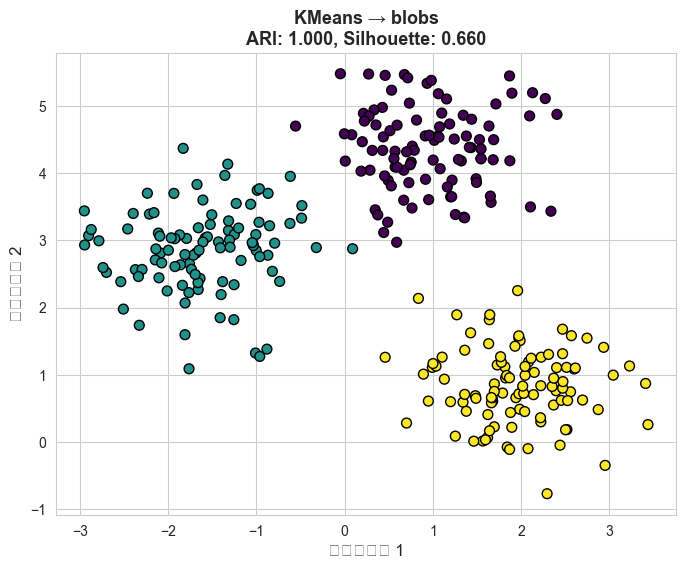

💡 উপরের কোডে ডেটাসেট, অ্যালগরিদম, এবং প্যারামিটার পরিবর্তন করে দেখো কী হয়!


In [10]:
# 🎯 তুমি এখানে নিজে এক্সপেরিমেন্ট করো!

my_dataset_choice = 'blobs'  # 'blobs', 'moons', 'circles'
my_algo_choice = 'KMeans'  # 'KMeans', 'Agglomerative', 'DBSCAN'
my_k_value = 3  # K-Means/Agglomerative-এর জন্য K
my_eps_value = 0.3  # DBSCAN-এর জন্য eps

if my_dataset_choice == 'blobs':
    X_exp, y_exp = make_blobs(300, centers=3, cluster_std=0.6, random_state=0)
elif my_dataset_choice == 'moons':
    X_exp, y_exp = make_moons(300, noise=0.08, random_state=0)
else:
    X_exp, y_exp = make_circles(300, noise=0.05, factor=0.5, random_state=0)

if my_algo_choice == 'KMeans':
    model = KMeans(n_clusters=my_k_value, random_state=42, n_init=10)
elif my_algo_choice == 'Agglomerative':
    model = AgglomerativeClustering(n_clusters=my_k_value, linkage='ward')
else:
    model = DBSCAN(eps=my_eps_value, min_samples=5)

y_exp_pred = model.fit_predict(X_exp)

ari_exp = adjusted_rand_score(y_exp, y_exp_pred)
mask_exp = y_exp_pred != -1
if mask_exp.sum() > 1 and len(set(y_exp_pred[mask_exp])) > 1:
    sil_exp = silhouette_score(X_exp[mask_exp], y_exp_pred[mask_exp])
else:
    sil_exp = -1
print(f"📊 ডেটাসেট: {my_dataset_choice}")
print(f"🎯 অ্যালগরিদম: {my_algo_choice}")
print(f"📈 ARI = {ari_exp:.4f}")
print(f"📈 Silhouette = {sil_exp:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(X_exp[:, 0], X_exp[:, 1], c=y_exp_pred, cmap='viridis', edgecolors='k', s=50)
plt.title(f'{my_algo_choice} → {my_dataset_choice}\nARI: {ari_exp:.3f}, Silhouette: {sil_exp:.3f}',
fontsize=13, fontweight='bold')
plt.xlabel('ফিচার 1', fontsize=12)
plt.ylabel('ফিচার 2', fontsize=12)
plt.show()
print("💡 উপরের কোডে ডেটাসেট, অ্যালগরিদম, এবং প্যারামিটার পরিবর্তন করে দেখো কী হয়!")

## 🌟 মজার তথ্য!

🎯 **Adjusted Rand Index**-এর নামকরণ William M. Rand-এর নামে — তিনি ১৯৭১ সালে এটি প্রস্তাব করেন।

🎯 **Silhouette Score** ১৯৮৭ সালে Peter J. Rousseeuw প্রস্তাব করেন। 'Silhouette' অর্থ ছায়া বা প্রতিবিম্ব — প্রতিটি ক্লাস্টারের "ছায়া" দেখে।

🎯 ARI-তে "Adjusted" মানে এটি এলোমেলো ক্লাস্টারিং-এর জন্যও ০ দেয় (সেইঞ্জমেন্টেড নয়)।

🎯 Silhouette Score-এর রেঞ্জ -১ থেকে +১ — কিন্তু বাস্তব জগতে সাধারণত ০.২ থেকে ০.৭-এর মধ্যে হয়। ০.৭+ খুব ভালো বলে মনে করা হয়।

🎯 ক্লাস্টারিং মূল্যায়নের আরও অনেক মেট্রিক আছে: **Homogeneity**, **Completeness**, **V-Measure**, **Davies-Bouldin Index**, **Calinski-Harabasz Index** ইত্যাদি।

## 🧠 তুমি কি বুঝতে পেরেছ?

❓ **প্রশ্ন ১**: ARI এবং Silhouette Score-এর মধ্যে প্রধান পার্থক্য কী?

❓ **প্রশ্ন ২**: ARI-র মান ১.০ হলে তার অর্থ কী?

❓ **প্রশ্ন ৩**: Silhouette Score-র মান নেগেটিভ হলে তার অর্থ কী?

❓ **প্রশ্ন ৪**: কোন ডেটাসেটের জন্য K-Means সবচেয়ে ভালো ARI দিয়েছে? কেন?

❓ **প্রশ্ন ৫**: কোন ডেটাসেটের জন্য DBSCAN সবচেয়ে ভালো ARI দিয়েছে? কেন?

---

**🧪 পরীক্ষা**: উপরের খেলার কোডে DBSCAN-এর eps = ০.১, ০.৩, ০.৫, ০.৮ দিয়ে দেখো ARI এবং Silhouette Score কীভাবে বদলায়।

---

**📝 মনে রেখো**:
- **ARI** = আসল লেবেল দরকার, গবেষণা ও পরীক্ষার জন্য
- **Silhouette Score** = আসল লেবেলের দরকার নেই, বাস্তব জগতের জন্য
- দুটি মেট্রিকই ০ থেকে ১-এর মধ্যে হয় (উন্নত)
- **Silhouette Score** K নির্বাচন করতেও সাহায্য করে
- **ভালো ক্লাস্টারিং** = পয়েন্ট নিজ ক্লাস্টারে কাছাকাছি, অন্য ক্লাস্টার থেকে দূরে
- ভিজুয়াল চেক সবসময় গুরুত্বপূর্ণ — শুধু সংখ্যার উপর নির্ভর না করা

---

## 🎉 অধ্যায় ৩-এর সমাপ্তি!

অভিনন্দন! তুমি অধ্যায় ৩ — "অতত্ত্বাবধানে শিক্ষণ" (Unsupervised Learning) সম্পূর্ণ করেছো! তুমি এখন জানো:

📌 **প্রিপ্রসেসিং ও স্কেলিং**: StandardScaler, MinMaxScaler, RobustScaler, Normalizer

📌 **PCA**: মাত্রা হ্রাস, উচ্চমাত্রার ডেটাকে ২D-তে ভিজুয়ালাইজ করা

📌 **NMF ও ম্যানিফোল্ড লার্নিং**: অংশ-ভিত্তিক পচন, t-SNE দিয়ে ভিজুয়ালাইজেশন

📌 **K-Means ক্লাস্টারিং**: ডেটাকে গ্রুপ করা, Elbow Method

📌 **Agglomerative ও DBSCAN**: হায়ারার্কিক্যাল ও ঘনত্ব-ভিত্তিক ক্লাস্টারিং

📌 **ক্লাস্টারিং মূল্যায়ন**: ARI ও Silhouette Score দিয়ে মান নির্ণয়

---

**তুমি এখন একজন জুনিয়র আনসুপারভাইজড লার্নিং এক্সপার্ট! 🏆**

পরবর্তী অধ্যায়ে আমরা ডেটা রিপ্রেজেন্টেশন ও ফিচার ইঞ্জিনিয়ারিং নিয়ে শিখব।